In [1]:
import pandas as pd
import os
import scanpy as sc
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import shutil
import anndata
from tqdm import tqdm
from scipy.stats import entropy
import matplotlib.patches as mpatches

In [2]:
adata_tme = sc.read_h5ad('/home/jupyter/data/ge_korea/results/ge_korea_final_annot_new.h5ad')


In [3]:
adata_t = sc.read_h5ad('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata_new_correct_progression.h5ad')
adata_t.obs['progression'] = adata_t.obs['patient'].map({
 'E30': 'Fast',
 'E26': 'Slow',
 'E15': 'Slow',
 'E21': 'Slow',
 'E43': 'Fast',
 'E37': 'Slow',
 'E14': 'Fast',
 'E44': 'Fast',
 'E36': 'Slow',
 'E42': 'Slow',
 'E31': 'Fast',
 'E17': 'Slow',
 'E38': 'Slow',
 'E16': 'Fast',
 'E24': 'Slow',
 'E22': 'Fast',
 'E45': 'Fast',
 'E35': 'Slow',
 'E33': 'Slow',
 'E27': 'Fast',
 'E23': 'Slow',
 'E34': 'Fast',
 'E39': 'Slow',
 'E25': 'Fast',
 'E41': 'Slow',
 'E12': 'Fast',
 'E18': 'Slow',
 'E20': 'Slow',
 'E32': 'Fast',
 'E46': 'Fast',
 'E40': 'Slow',
 'E29': 'Slow',
 'E19': 'Fast'})
temp = adata_t.obs[['patient','progression']].drop_duplicates()
temp.index = temp['patient']
progression_dict = temp['progression'].to_dict()
adata_tme.obs['progression'] = adata_tme.obs['patient'].map(
    progression_dict)

In [4]:
adata_tme = adata_tme[~adata_tme.obs['normal'].isin(['AN','DN'])]

# Broad B

In [5]:
cell_types = [
    'B', 'Treg','Tactiv Cell','CD8 Tem Cell','Th17',
    'GZMK+ CD8 T progenitor ex Cell','T naive/early memory Cell','Th17/Tc17',
    'gd T Cell','Tc17','CD8 Cytotoxic T Cell','CD8 HSP T cell','Tprolif Cell',
    'NKT','Terminal CD8 Tex Cell']
adata_tme = adata_tme[adata_tme.obs['annot_final'].isin(
    ['B', 'Treg','Tactiv Cell','CD8 Tem Cell','Th17',
    'GZMK+ CD8 T progenitor ex Cell','T naive/early memory Cell','Th17/Tc17',
    'gd T Cell','Tc17','CD8 Cytotoxic T Cell','CD8 HSP T cell','Tprolif Cell',
    'NKT','Terminal CD8 Tex Cell']
)]

In [6]:
genes = [
    'CD80','CD86','CXCL13','CD40LG','TGFB1','SELPLG','IL7','IFNG',
    'ICOSLG','FASLG','CCL20','CXCR5','CD28','CD40','SELL','ICOS','FAS',
    'CTLA4','CCR6','TGFBR1','TGFBR2','TGFBR3','IL2RG','IL7R','IFNGR1','IFNGR2',
    'TNFSF13B','TNFRSF13C','TNFRSF13B','SEMA4D','CD72']

In [7]:
avg_b_slow = pd.DataFrame(np.nan, index=cell_types, columns=genes)
avg_f1_slow = pd.DataFrame(np.nan, index=cell_types, columns=genes)
avg_f2_slow = pd.DataFrame(np.nan, index=cell_types, columns=genes)

avg_b_fast = pd.DataFrame(np.nan, index=cell_types, columns=genes)
avg_f1_fast = pd.DataFrame(np.nan, index=cell_types, columns=genes)
avg_f2_fast = pd.DataFrame(np.nan, index=cell_types, columns=genes)

for i in genes:    
    for j in cell_types:
        avg_b_slow.loc[j,i] = adata_tme[(adata_tme.obs['annot_final'] == j) & (
            adata_tme.obs['timepoint'] == 'B'
        ) & (adata_tme.obs['progression'] == 'Slow')][:,i].to_df().mean()[0]

        avg_f1_slow.loc[j,i] = adata_tme[(adata_tme.obs['annot_final'] == j) & (
            adata_tme.obs['timepoint'] == 'F1'
        ) & (adata_tme.obs['progression'] == 'Slow')][:,i].to_df().mean()[0]

        avg_f2_slow.loc[j,i] = adata_tme[(adata_tme.obs['annot_final'] == j) & (
            adata_tme.obs['timepoint'] == 'F2'
        ) & (adata_tme.obs['progression'] == 'Slow')][:,i].to_df().mean()[0]

        avg_b_fast.loc[j,i] = adata_tme[(adata_tme.obs['annot_final'] == j) & (
            adata_tme.obs['timepoint'] == 'B'
        ) & (adata_tme.obs['progression'] == 'Fast')][:,i].to_df().mean()[0]

        avg_f1_fast.loc[j,i] = adata_tme[(adata_tme.obs['annot_final'] == j) & (
            adata_tme.obs['timepoint'] == 'F1'
        ) & (adata_tme.obs['progression'] == 'Fast')][:,i].to_df().mean()[0]

        avg_f2_fast.loc[j,i] = adata_tme[(adata_tme.obs['annot_final'] == j) & (
            adata_tme.obs['timepoint'] == 'F2'
        ) & (adata_tme.obs['progression'] == 'Fast')][:,i].to_df().mean()[0]

In [8]:
interactions = [
    'CD80-CD28','CD86-CD28','CXCL13-CXCR5','CD40LG-CD40','TGFB1-TGFBR1-TGFBR2','TGFB1-TGFBR3',
    'SELPLG-SELL','IL7-IL2RG-IL7R','IFNG-IFNGR1-IFNGR2','ICOSLG-ICOS','FASLG-FAS','CD86-CTLA4',
    'CD80-CTLA4','CCL20-CCR6','TNFSF13B-TNFRSF13C','TNFSF13B-TNFRSF13B','SEMA4D-CD72'
]

In [9]:
import itertools
slow_b_interaction_score = pd.DataFrame(
    np.nan, index=list(itertools.permutations(cell_types,2)), columns=interactions)
slow_f1_interaction_score = pd.DataFrame(
    np.nan, index=list(itertools.permutations(cell_types,2)), columns=interactions)
slow_f2_interaction_score = pd.DataFrame(
    np.nan, index=list(itertools.permutations(cell_types,2)), columns=interactions)
fast_b_interaction_score = pd.DataFrame(
    np.nan, index=list(itertools.permutations(cell_types,2)), columns=interactions)
fast_f1_interaction_score = pd.DataFrame(
    np.nan, index=list(itertools.permutations(cell_types,2)), columns=interactions)
fast_f2_interaction_score = pd.DataFrame(
    np.nan, index=list(itertools.permutations(cell_types,2)), columns=interactions)
for i, j in itertools.permutations(cell_types, 2):
    for k in interactions:
        temp = k.split('-')
        if len(temp) == 2:  
            slow_b_interaction_score.loc[[(i,j)],k] = np.min([
            avg_b_slow.loc[i,k.split('-')[0]],
            avg_b_slow.loc[j,k.split('-')[1]]])
    
            slow_f1_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f1_slow.loc[i,k.split('-')[0]],
                avg_f1_slow.loc[j,k.split('-')[1]]])
                                                           
            slow_f2_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f2_slow.loc[i,k.split('-')[0]],
                avg_f2_slow.loc[j,k.split('-')[1]]])
    
            fast_b_interaction_score.loc[[(i,j)],k] = np.min([
                avg_b_fast.loc[i,k.split('-')[0]],
                avg_b_fast.loc[j,k.split('-')[1]]])
    
            fast_f1_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f1_fast.loc[i,k.split('-')[0]],
                avg_f1_fast.loc[j,k.split('-')[1]]])
    
            fast_f2_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f2_fast.loc[i,k.split('-')[0]],
                avg_f2_fast.loc[j,k.split('-')[1]]])
        if len(temp) == 3:
            slow_b_interaction_score.loc[[(i,j)],k] = np.min([
                avg_b_slow.loc[i,k.split('-')[0]],
                avg_b_slow.loc[j,k.split('-')[1]],
                avg_b_slow.loc[j,k.split('-')[2]]])
    
            slow_f1_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f1_slow.loc[i,k.split('-')[0]],
                avg_f1_slow.loc[j,k.split('-')[1]],
                avg_f1_slow.loc[j,k.split('-')[2]]])
                                                           
            slow_f2_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f2_slow.loc[i,k.split('-')[0]],
                avg_f2_slow.loc[j,k.split('-')[1]],
                avg_f2_slow.loc[j,k.split('-')[2]]])
    
            fast_b_interaction_score.loc[[(i,j)],k] = np.min([
                avg_b_fast.loc[i,k.split('-')[0]],
                avg_b_fast.loc[j,k.split('-')[1]],
                avg_b_fast.loc[j,k.split('-')[2]]])
    
            fast_f1_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f1_fast.loc[i,k.split('-')[0]],
                avg_f1_fast.loc[j,k.split('-')[1]],
                avg_f1_fast.loc[j,k.split('-')[2]]])
    
            fast_f2_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f2_fast.loc[i,k.split('-')[0]],
                avg_f2_fast.loc[j,k.split('-')[1]],
                avg_f2_fast.loc[j,k.split('-')[2]]])

In [10]:
b_cells = ['B']

t_cells = ['Treg','Tactiv Cell','CD8 Tem Cell','Th17',
    'GZMK+ CD8 T progenitor ex Cell','T naive/early memory Cell','Th17/Tc17',
    'gd T Cell','Tc17','CD8 Cytotoxic T Cell','CD8 HSP T cell','Tprolif Cell',
    'NKT','Terminal CD8 Tex Cell']

In [11]:
b_t = []
t_b = []
for i in b_cells:
    for j in t_cells:
        b_t.append((i,j))
        t_b.append((j,i))

In [12]:
cd80cd28 = pd.DataFrame({
    'Slow B' : slow_b_interaction_score.loc[b_t]['CD80-CD28'],
    'Slow F1' : slow_f1_interaction_score.loc[b_t]['CD80-CD28'],
    'Slow F2' : slow_f2_interaction_score.loc[b_t]['CD80-CD28'],
    'Fast B' : fast_b_interaction_score.loc[b_t]['CD80-CD28'],
    'Fast F1' : fast_f1_interaction_score.loc[b_t]['CD80-CD28'],
    'Fast F2' : fast_f2_interaction_score.loc[b_t]['CD80-CD28']}).fillna(0)

Text(0.5, 1.0, 'Estimated CD80-CD28 Interaction Strengths')

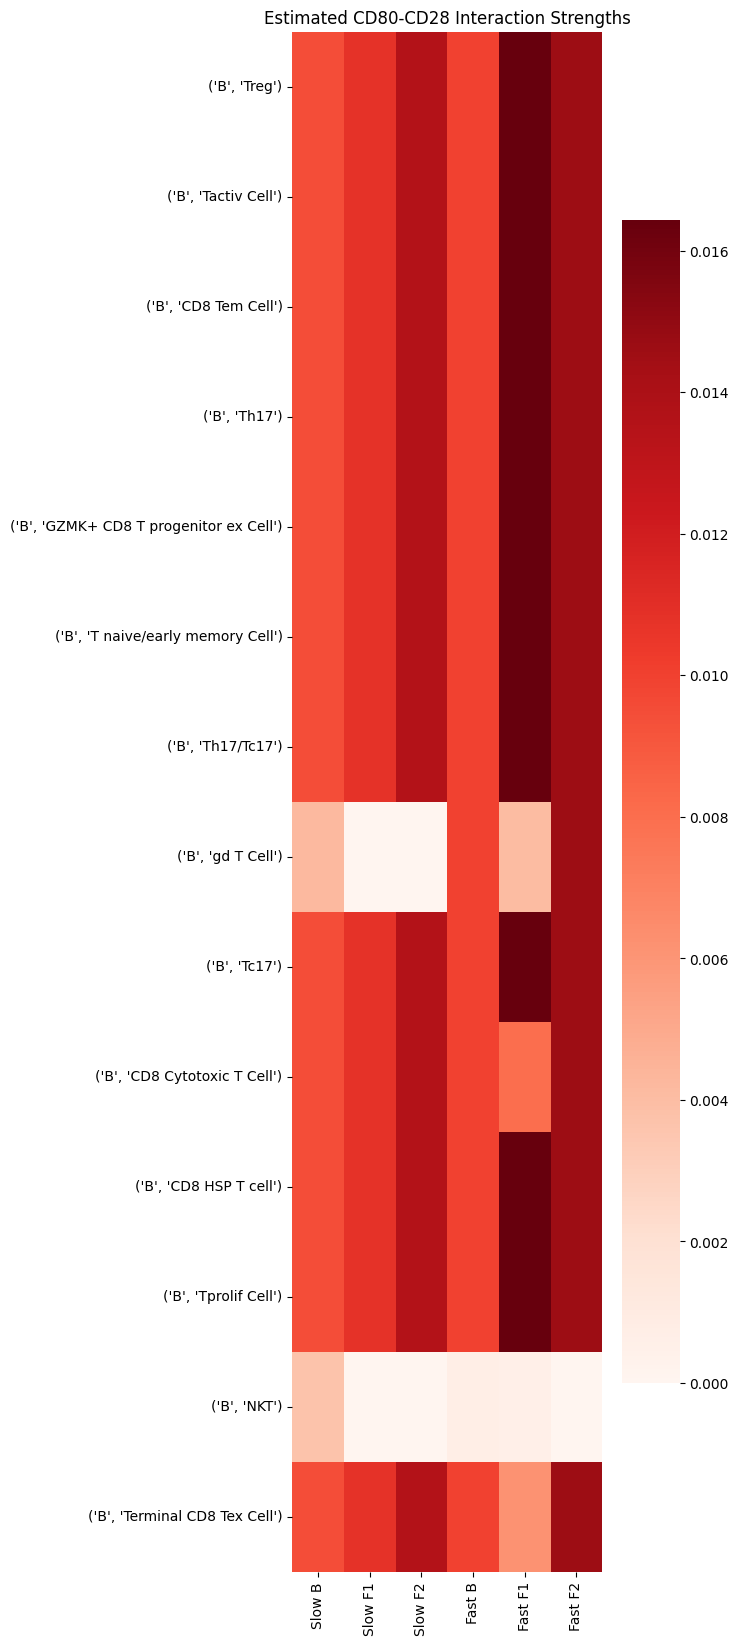

In [13]:
from scipy.stats import zscore
plt.figure(figsize=(5,20))
sns.heatmap(cd80cd28,cmap='Reds',yticklabels=1)
plt.title('Estimated CD80-CD28 Interaction Strengths')

In [14]:
temp_interactions = [
    ('Treg', 'B'),('Tprolif Cell', 'B'),('Terminal CD8 Tex Cell', 'B'),('GZMK+ CD8 T progenitor ex Cell', 'B')]
cxcl13cxcr5 = pd.DataFrame({
    'Slow B' : slow_b_interaction_score.loc[temp_interactions]['CXCL13-CXCR5'],
    'Slow F1' : slow_f1_interaction_score.loc[temp_interactions]['CXCL13-CXCR5'],
    'Slow F2' : slow_f2_interaction_score.loc[temp_interactions]['CXCL13-CXCR5'],
    'Fast B' : fast_b_interaction_score.loc[temp_interactions]['CXCL13-CXCR5'],
    'Fast F1' : fast_f1_interaction_score.loc[temp_interactions]['CXCL13-CXCR5'],
    'Fast F2' : fast_f2_interaction_score.loc[temp_interactions]['CXCL13-CXCR5']}).fillna(0)

Text(0.5, 1.0, 'Estimated CXCL13-CXCR5 Interaction Strengths')

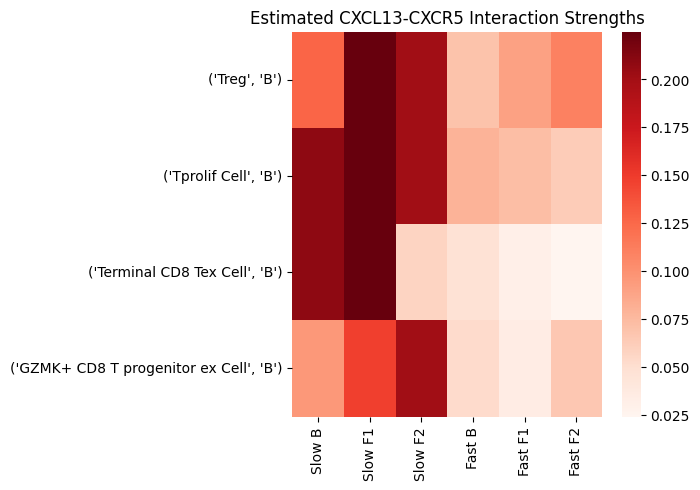

In [15]:
from scipy.stats import zscore
plt.figure(figsize=(5,5))
sns.heatmap(cxcl13cxcr5,cmap='Reds',yticklabels=1)
plt.title('Estimated CXCL13-CXCR5 Interaction Strengths')

In [16]:
temp_interactions = [
    ('T naive/early memory Cell', 'B'),('Th17', 'B'),('Th17/Tc17', 'B')
]

In [17]:
cd40lgcd40 = pd.DataFrame({
    'Slow B' : slow_b_interaction_score.loc[temp_interactions]['CD40LG-CD40'],
    'Slow F1' : slow_f1_interaction_score.loc[temp_interactions]['CD40LG-CD40'],
    'Slow F2' : slow_f2_interaction_score.loc[temp_interactions]['CD40LG-CD40'],
    'Fast B' : fast_b_interaction_score.loc[temp_interactions]['CD40LG-CD40'],
    'Fast F1' : fast_f1_interaction_score.loc[temp_interactions]['CD40LG-CD40'],
    'Fast F2' : fast_f2_interaction_score.loc[temp_interactions]['CD40LG-CD40']}).fillna(0)

Text(0.5, 1.0, 'Estimated CD40LG-CD40 Interaction Strengths')

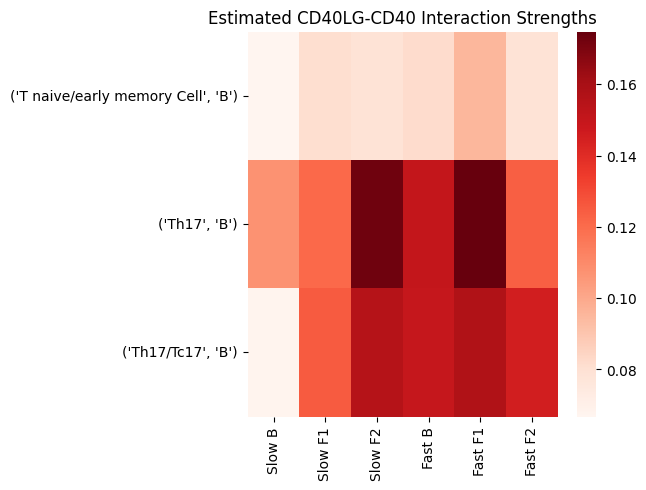

In [18]:
from scipy.stats import zscore
plt.figure(figsize=(5,5))
sns.heatmap(cd40lgcd40,cmap='Reds',yticklabels=1)
plt.title('Estimated CD40LG-CD40 Interaction Strengths')

In [19]:
temp_interactions = [
    ('B', 'gd T Cell'),('B', 'Tprolif Cell')
]

In [20]:
tgfb1tgfbr1 = pd.DataFrame({
    'Slow B' : slow_b_interaction_score.loc[temp_interactions]['TGFB1-TGFBR1-TGFBR2'],
    'Slow F1' : slow_f1_interaction_score.loc[temp_interactions]['TGFB1-TGFBR1-TGFBR2'],
    'Slow F2' : slow_f2_interaction_score.loc[temp_interactions]['TGFB1-TGFBR1-TGFBR2'],
    'Fast B' : fast_b_interaction_score.loc[temp_interactions]['TGFB1-TGFBR1-TGFBR2'],
    'Fast F1' : fast_f1_interaction_score.loc[temp_interactions]['TGFB1-TGFBR1-TGFBR2'],
    'Fast F2' : fast_f2_interaction_score.loc[temp_interactions]['TGFB1-TGFBR1-TGFBR2']}).fillna(0)

Text(0.5, 1.0, 'Estimated TGFB1-TGFBR1-TGFBR2 Interaction Strengths')

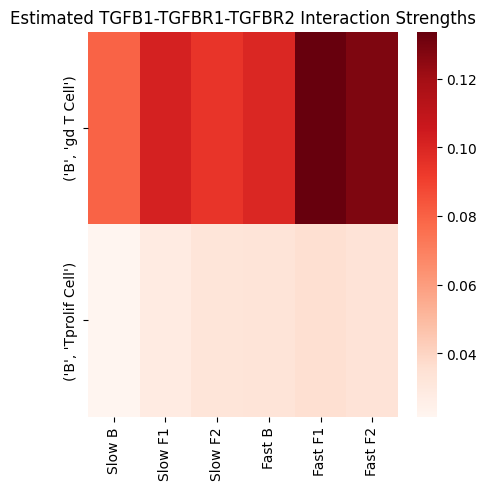

In [21]:
from scipy.stats import zscore
plt.figure(figsize=(5,5))
sns.heatmap(tgfb1tgfbr1,cmap='Reds',yticklabels=1)
plt.title('Estimated TGFB1-TGFBR1-TGFBR2 Interaction Strengths')

In [22]:
temp_interactions = [
('Tactiv Cell', 'B'),('Tprolif Cell', 'B'),('gd T Cell', 'B'),
]

In [23]:
ifngifngr = pd.DataFrame({
    'Slow B' : slow_b_interaction_score.loc[temp_interactions]['IFNG-IFNGR1-IFNGR2'],
    'Slow F1' : slow_f1_interaction_score.loc[temp_interactions]['IFNG-IFNGR1-IFNGR2'],
    'Slow F2' : slow_f2_interaction_score.loc[temp_interactions]['IFNG-IFNGR1-IFNGR2'],
    'Fast B' : fast_b_interaction_score.loc[temp_interactions]['IFNG-IFNGR1-IFNGR2'],
    'Fast F1' : fast_f1_interaction_score.loc[temp_interactions]['IFNG-IFNGR1-IFNGR2'],
    'Fast F2' : fast_f2_interaction_score.loc[temp_interactions]['IFNG-IFNGR1-IFNGR2']}).fillna(0)

Text(0.5, 1.0, 'Estimated IFNG-IFNGR1-IFNGR2 Interaction Strengths')

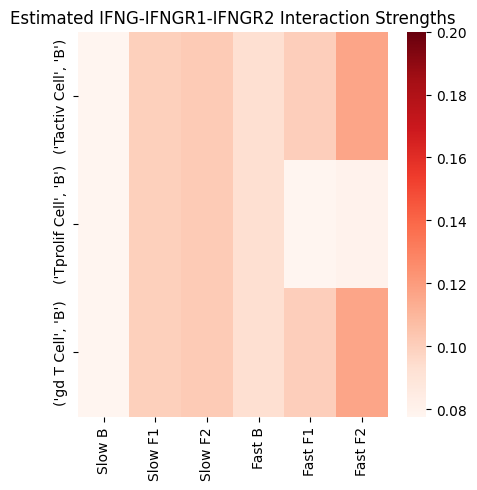

In [24]:
from scipy.stats import zscore
plt.figure(figsize=(5,5))
sns.heatmap(ifngifngr,cmap='Reds',yticklabels=1,vmax=0.2)
plt.title('Estimated IFNG-IFNGR1-IFNGR2 Interaction Strengths')

In [25]:
temp_interactions = [
    ('Tc17', 'B'),('Th17', 'B'),('Th17/Tc17', 'B'),('Tprolif Cell', 'B'),('Treg', 'B'),
]

In [26]:
ccl20ccr6 = pd.DataFrame({
    'Slow B' : slow_b_interaction_score.loc[temp_interactions]['CCL20-CCR6'],
    'Slow F1' : slow_f1_interaction_score.loc[temp_interactions]['CCL20-CCR6'],
    'Slow F2' : slow_f2_interaction_score.loc[temp_interactions]['CCL20-CCR6'],
    'Fast B' : fast_b_interaction_score.loc[temp_interactions]['CCL20-CCR6'],
    'Fast F1' : fast_f1_interaction_score.loc[temp_interactions]['CCL20-CCR6'],
    'Fast F2' : fast_f2_interaction_score.loc[temp_interactions]['CCL20-CCR6']}).fillna(0)

Text(0.5, 1.0, 'Estimated CCL20-CCR6 Interaction Strengths')

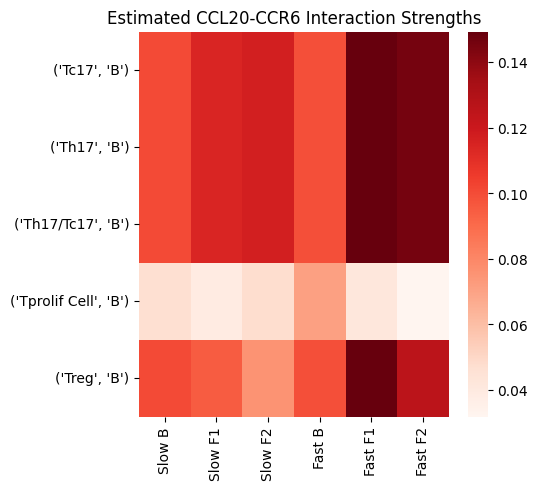

In [27]:
from scipy.stats import zscore
plt.figure(figsize=(5,5))
sns.heatmap(ccl20ccr6,cmap='Reds',yticklabels=1)
plt.title('Estimated CCL20-CCR6 Interaction Strengths')

# Broad T

In [28]:
adata_tme = sc.read_h5ad('/home/jupyter/data/ge_korea/results/ge_korea_final_annot_new.h5ad')
adata_tme=adata_tme[~adata_tme.obs['patient'].isin(['E36','E37','E43','E45'])]

In [29]:
adata_b = sc.read_h5ad('/home/jupyter/data/ge_korea/results/ge_korea_b_annotation.h5ad')
adata_b=adata_b[~adata_b.obs['patient'].isin(['E36','E37','E43','E45'])]

In [30]:
adata_tme.obs['annot_final_new'] = pd.concat([adata_tme[~adata_tme.obs['annot_final'].isin(['B'])].obs['annot_final'],
                                   adata_b.obs['annot_3rd']])

/tmp/ipykernel_1490/3946992368.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_tme.obs['annot_final_new'] = pd.concat([adata_tme[~adata_tme.obs['annot_final'].isin(['B'])].obs['annot_final'],


In [31]:
adata_t = sc.read_h5ad('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata_new_correct_progression.h5ad')
adata_t=adata_t[~adata_t.obs['patient'].isin(['E36','E37','E43','E45'])]
temp = adata_t.obs[['patient','progression']].drop_duplicates()
temp.index = temp['patient']
progression_dict = temp['progression'].to_dict()
adata_tme.obs['progression'] = adata_tme.obs['patient'].map(
    progression_dict)

In [32]:
adata_tme = adata_tme[~adata_tme.obs['normal'].isin(['AN','DN'])]

In [33]:
broad_cell_types = {
 'Plasma' : 'Plasma',
 'Activated B Cell' : 'Activated B Cell',
 'Resting Memory B Cell' : 'Resting Memory B Cell',
 'Naive B Cell' : 'Naive B Cell',
 'Atypical Memory B Cell' : 'Atypical Memory B Cell',
 'GC/Proliferative B Cell' : 'GC/Proliferative B Cell',
 'EIF6+ B Cell' : 'EIF6+ B Cell',
 'Epithelial' : 'Epithelial',
 'Capillary Endothelial' : 'Capillary Endothelial',
 'Pericyte' : 'Pericyte',
 'iCAF' : 'iCAF',
 'Venuous Endothelial' : 'Veuous Endothelial',
 'SMC' : 'SMC',
 'Schwann' : 'Schwann',
 'Lymphatic Endothelial' : 'Lymphatic Endothelial',
 'C1QC Macrophage' : 'C1QC Macrophage',
 'cDC2' : 'cDC2',
 'Monocyte' : 'Monocyte',
 'CD14 Monocyte' : 'CD14 Monocyte',
 'Mast' : 'Mast',
 'mregDC' : 'mregDC',
 'SPP1 Macrophage' : 'SPP1 Macrophage',
 'cDC1' : 'cDC1', 
 'pDC' : 'pDC',
 'Treg' : 'Treg',
 'Tactiv Cell' : 'T',
 'CD8 Tem Cell' : 'T',
 'Th17' : 'T',
 'CD4 T naive/early memory Cell' : 'T',
 'GZMK+ CD8 T progrenitor ex Cell' : 'T',
 'Th17/Tc17' : 'T',
 'NK' : 'NK',
 'gd T Cell' : 'T', 
 'Tc17' : 'T',
 'CD8 T naive/early memory Cell' : 'T',
 'CD8 Cytotoxic T Cell' : 'T',
 'CD8 HSP T cell' : 'T',
 'Tprolif Cell' : 'T',
 'NKT' : 'T',
 'Terminal CD8 Tex Cell' : 'T',
 'T naive/early memory Cell' : 'T',
 'Tnaive Cell' : 'T'
}

In [34]:
adata_tme.obs['broad_cell_types_t'] = adata_tme.obs['annot_final_new'].map(broad_cell_types)

/tmp/ipykernel_1490/2246758730.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_tme.obs['broad_cell_types_t'] = adata_tme.obs['annot_final_new'].map(broad_cell_types)


In [35]:
cell_types = ['Activated B Cell', 'Resting Memory B Cell',
       'Naive B Cell', 'Atypical Memory B Cell',
       'GC/Proliferative B Cell', 'EIF6+ B Cell', 'Treg', 'T']
adata_tme = adata_tme[adata_tme.obs['broad_cell_types_t'].isin(
    ['Activated B Cell', 'Resting Memory B Cell',
       'Naive B Cell', 'Atypical Memory B Cell',
       'GC/Proliferative B Cell', 'EIF6+ B Cell', 'Treg', 'T']
)]

In [36]:
adata_tme.obs['broad_cell_types_t'].unique().tolist()

['Activated B Cell',
 'Resting Memory B Cell',
 'Naive B Cell',
 'Atypical Memory B Cell',
 'GC/Proliferative B Cell',
 'EIF6+ B Cell',
 'Treg',
 'T']

In [37]:
genes = [
    'CD80','CD86','CXCL13','CD40LG','TGFB1','SELPLG','IL7','IFNG',
    'ICOSLG','FASLG','CCL20','CXCR5','CD28','CD40','SELL','ICOS','FAS',
    'CTLA4','CCR6','TGFBR1','TGFBR2','TGFBR3','IL2RG','IL7R','IFNGR1','IFNGR2',
    'TNFSF13B','TNFRSF13C','TNFRSF13B','SEMA4D','CD72']

In [38]:
avg_b_slow = pd.DataFrame(np.nan, index=cell_types, columns=genes)
avg_f1_slow = pd.DataFrame(np.nan, index=cell_types, columns=genes)
avg_f2_slow = pd.DataFrame(np.nan, index=cell_types, columns=genes)

avg_b_fast = pd.DataFrame(np.nan, index=cell_types, columns=genes)
avg_f1_fast = pd.DataFrame(np.nan, index=cell_types, columns=genes)
avg_f2_fast = pd.DataFrame(np.nan, index=cell_types, columns=genes)

for i in genes:    
    for j in cell_types:
        avg_b_slow.loc[j,i] = adata_tme[(adata_tme.obs['broad_cell_types_t'] == j) & (
            adata_tme.obs['timepoint'] == 'B'
        ) & (adata_tme.obs['progression'] == 'Slow')][:,i].to_df().mean()[0]

        avg_f1_slow.loc[j,i] = adata_tme[(adata_tme.obs['broad_cell_types_t'] == j) & (
            adata_tme.obs['timepoint'] == 'F1'
        ) & (adata_tme.obs['progression'] == 'Slow')][:,i].to_df().mean()[0]

        avg_f2_slow.loc[j,i] = adata_tme[(adata_tme.obs['broad_cell_types_t'] == j) & (
            adata_tme.obs['timepoint'] == 'F2'
        ) & (adata_tme.obs['progression'] == 'Slow')][:,i].to_df().mean()[0]

        avg_b_fast.loc[j,i] = adata_tme[(adata_tme.obs['broad_cell_types_t'] == j) & (
            adata_tme.obs['timepoint'] == 'B'
        ) & (adata_tme.obs['progression'] == 'Fast')][:,i].to_df().mean()[0]

        avg_f1_fast.loc[j,i] = adata_tme[(adata_tme.obs['broad_cell_types_t'] == j) & (
            adata_tme.obs['timepoint'] == 'F1'
        ) & (adata_tme.obs['progression'] == 'Fast')][:,i].to_df().mean()[0]

        avg_f2_fast.loc[j,i] = adata_tme[(adata_tme.obs['broad_cell_types_t'] == j) & (
            adata_tme.obs['timepoint'] == 'F2'
        ) & (adata_tme.obs['progression'] == 'Fast')][:,i].to_df().mean()[0]

In [39]:
interactions = [
    'CD80-CD28','CD86-CD28','CXCL13-CXCR5','CD40LG-CD40','TGFB1-TGFBR1-TGFBR2','TGFB1-TGFBR3',
    'SELPLG-SELL','IL7-IL2RG-IL7R','IFNG-IFNGR1-IFNGR2','ICOSLG-ICOS','FASLG-FAS','CD86-CTLA4',
    'CD80-CTLA4','CCL20-CCR6','TNFSF13B-TNFRSF13C','TNFSF13B-TNFRSF13B','SEMA4D-CD72'
]

In [40]:
import itertools
slow_b_interaction_score = pd.DataFrame(
    np.nan, index=list(itertools.permutations(cell_types,2)), columns=interactions)
slow_f1_interaction_score = pd.DataFrame(
    np.nan, index=list(itertools.permutations(cell_types,2)), columns=interactions)
slow_f2_interaction_score = pd.DataFrame(
    np.nan, index=list(itertools.permutations(cell_types,2)), columns=interactions)
fast_b_interaction_score = pd.DataFrame(
    np.nan, index=list(itertools.permutations(cell_types,2)), columns=interactions)
fast_f1_interaction_score = pd.DataFrame(
    np.nan, index=list(itertools.permutations(cell_types,2)), columns=interactions)
fast_f2_interaction_score = pd.DataFrame(
    np.nan, index=list(itertools.permutations(cell_types,2)), columns=interactions)
for i, j in itertools.permutations(cell_types, 2):
    for k in interactions:
        temp = k.split('-')
        if len(temp) == 2:  
            slow_b_interaction_score.loc[[(i,j)],k] = np.min([
            avg_b_slow.loc[i,k.split('-')[0]],
            avg_b_slow.loc[j,k.split('-')[1]]])
    
            slow_f1_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f1_slow.loc[i,k.split('-')[0]],
                avg_f1_slow.loc[j,k.split('-')[1]]])
                                                           
            slow_f2_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f2_slow.loc[i,k.split('-')[0]],
                avg_f2_slow.loc[j,k.split('-')[1]]])
    
            fast_b_interaction_score.loc[[(i,j)],k] = np.min([
                avg_b_fast.loc[i,k.split('-')[0]],
                avg_b_fast.loc[j,k.split('-')[1]]])
    
            fast_f1_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f1_fast.loc[i,k.split('-')[0]],
                avg_f1_fast.loc[j,k.split('-')[1]]])
    
            fast_f2_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f2_fast.loc[i,k.split('-')[0]],
                avg_f2_fast.loc[j,k.split('-')[1]]])
        if len(temp) == 3:
            slow_b_interaction_score.loc[[(i,j)],k] = np.min([
                avg_b_slow.loc[i,k.split('-')[0]],
                avg_b_slow.loc[j,k.split('-')[1]],
                avg_b_slow.loc[j,k.split('-')[2]]])
    
            slow_f1_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f1_slow.loc[i,k.split('-')[0]],
                avg_f1_slow.loc[j,k.split('-')[1]],
                avg_f1_slow.loc[j,k.split('-')[2]]])
                                                           
            slow_f2_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f2_slow.loc[i,k.split('-')[0]],
                avg_f2_slow.loc[j,k.split('-')[1]],
                avg_f2_slow.loc[j,k.split('-')[2]]])
    
            fast_b_interaction_score.loc[[(i,j)],k] = np.min([
                avg_b_fast.loc[i,k.split('-')[0]],
                avg_b_fast.loc[j,k.split('-')[1]],
                avg_b_fast.loc[j,k.split('-')[2]]])
    
            fast_f1_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f1_fast.loc[i,k.split('-')[0]],
                avg_f1_fast.loc[j,k.split('-')[1]],
                avg_f1_fast.loc[j,k.split('-')[2]]])
    
            fast_f2_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f2_fast.loc[i,k.split('-')[0]],
                avg_f2_fast.loc[j,k.split('-')[1]],
                avg_f2_fast.loc[j,k.split('-')[2]]])

In [41]:
avg_b_slow

,CD80,CD86,CXCL13,CD40LG,TGFB1,SELPLG,IL7,IFNG,ICOSLG,FASLG,...,TGFBR3,IL2RG,IL7R,IFNGR1,IFNGR2,TNFSF13B,TNFRSF13C,TNFRSF13B,SEMA4D,CD72
Activated B Cell,0.013518,0.062662,0.006320,0.000000,0.518707,0.008488,0.019053,0.001198,0.037960,0.000000,...,0.000000,0.279006,0.005210,0.064766,0.142275,0.005837,0.179814,0.200204,0.070934,0.115422
Resting Memory B Cell,0.009330,0.064187,0.000849,0.000000,0.587521,0.003857,0.025489,0.000315,0.027434,0.000753,...,0.002056,0.327235,0.004111,0.069341,0.160082,0.001833,0.222095,0.291698,0.088760,0.074966
Naive B Cell,0.000000,0.015144,0.000000,0.000523,0.620991,0.005770,0.021535,0.000813,0.066171,0.000000,...,0.000000,0.375879,0.004570,0.117458,0.177744,0.004233,0.190907,0.055753,0.044636,0.329116
Atypical Memory B Cell,0.020308,0.135587,0.000000,0.000000,0.640012,0.004129,0.048507,0.004707,0.021567,0.004590,...,0.000000,0.522285,0.000000,0.100288,0.217747,0.022921,0.212038,0.370128,0.127406,0.101982
GC/Proliferative B Cell,0.016709,0.228112,0.000000,0.000000,0.370771,0.000000,0.000000,0.000000,0.061751,0.000000,...,0.000000,0.319274,0.000000,0.027492,0.111351,0.003986,0.309136,0.065944,0.154709,0.173639
EIF6+ B Cell,0.044247,0.098300,0.080824,0.000000,0.459657,0.000000,0.000000,0.046050,0.054475,0.017372,...,0.000000,0.550701,0.000000,0.071152,0.109220,0.000000,0.267276,0.084941,0.048516,0.148098
Treg,0.024636,0.008720,0.133150,0.050003,0.481085,0.351121,0.017656,0.021170,0.001206,0.017491,...,0.025101,1.061011,0.777698,0.076981,0.024928,0.040167,0.002645,0.029907,0.109526,0.006180
T,0.003413,0.004901,0.072373,0.044011,0.674564,0.242624,0.002903,0.063435,0.001202,0.094420,...,0.058901,0.797274,0.813738,0.128557,0.010789,0.055549,0.003239,0.002627,0.146869,0.006144


In [42]:
b_cells = ['Activated B Cell', 'Resting Memory B Cell',
       'Naive B Cell', 'Atypical Memory B Cell',
       'GC/Proliferative B Cell', 'EIF6+ B Cell']

t_cells = ['Treg', 'T']

In [43]:
b_t = []
t_b = []
for i in b_cells:
    for j in t_cells:
        b_t.append((i,j))
        t_b.append((j,i))

In [44]:
cd80cd28 = pd.DataFrame({
    'Slow B' : slow_b_interaction_score.loc[b_t]['CD80-CD28'],
    'Slow F1' : slow_f1_interaction_score.loc[b_t]['CD80-CD28'],
    'Slow F2' : slow_f2_interaction_score.loc[b_t]['CD80-CD28'],
    'Fast B' : fast_b_interaction_score.loc[b_t]['CD80-CD28'],
    'Fast F1' : fast_f1_interaction_score.loc[b_t]['CD80-CD28'],
    'Fast F2' : fast_f2_interaction_score.loc[b_t]['CD80-CD28']}).fillna(0)

Text(0.5, 1.0, 'Estimated CD80-CD28 Interaction Strengths')

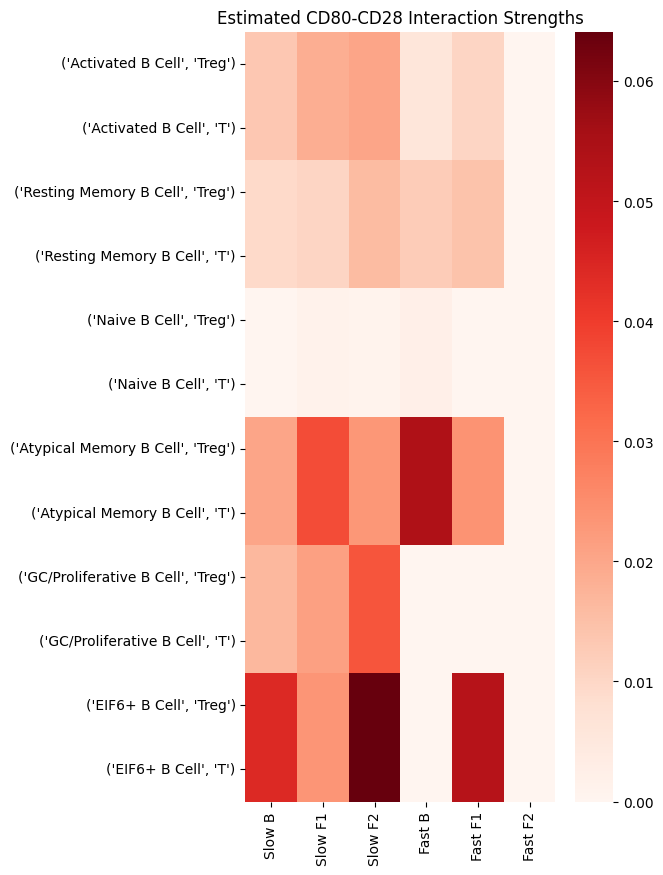

In [45]:
from scipy.stats import zscore
plt.figure(figsize=(5,10))
sns.heatmap(cd80cd28,cmap='Reds',yticklabels=1)
plt.title('Estimated CD80-CD28 Interaction Strengths')

In [46]:
temp_interactions = [
    ('Treg', 'EIF6+ B Cell'),
 ('T', 'EIF6+ B Cell')
]

In [47]:
tgfb1tgfbr1 = pd.DataFrame({
    'Slow B' : slow_b_interaction_score.loc[temp_interactions]['TGFB1-TGFBR1-TGFBR2'],
    'Slow F1' : slow_f1_interaction_score.loc[temp_interactions]['TGFB1-TGFBR1-TGFBR2'],
    'Slow F2' : slow_f2_interaction_score.loc[temp_interactions]['TGFB1-TGFBR1-TGFBR2'],
    'Fast B' : fast_b_interaction_score.loc[temp_interactions]['TGFB1-TGFBR1-TGFBR2'],
    'Fast F1' : fast_f1_interaction_score.loc[temp_interactions]['TGFB1-TGFBR1-TGFBR2'],
    'Fast F2' : fast_f2_interaction_score.loc[temp_interactions]['TGFB1-TGFBR1-TGFBR2']}).fillna(0)

Text(0.5, 1.0, 'Estimated TGFB1-TGFBR1-TGFBR2 Interaction Strengths')

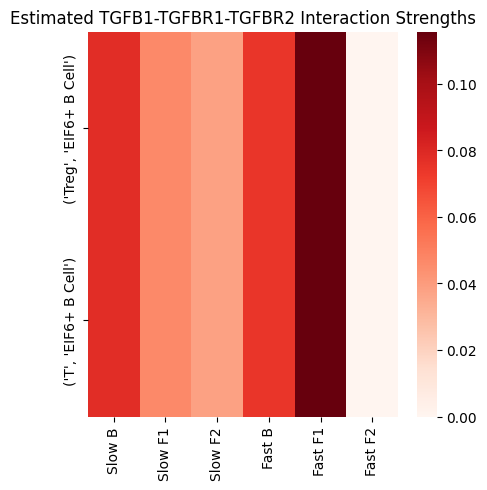

In [48]:
from scipy.stats import zscore
plt.figure(figsize=(5,5))
sns.heatmap(tgfb1tgfbr1,cmap='Reds',yticklabels=1)
plt.title('Estimated TGFB1-TGFBR1-TGFBR2 Interaction Strengths')

In [49]:
temp_interactions = [
    ('GC/Proliferative B Cell', 'Treg'),
 ('GC/Proliferative B Cell', 'T')
]

In [50]:
il7il7r = pd.DataFrame({
    'Slow B' : slow_b_interaction_score.loc[temp_interactions]['IL7-IL2RG-IL7R'],
    'Slow F1' : slow_f1_interaction_score.loc[temp_interactions]['IL7-IL2RG-IL7R'],
    'Slow F2' : slow_f2_interaction_score.loc[temp_interactions]['IL7-IL2RG-IL7R'],
    'Fast B' : fast_b_interaction_score.loc[temp_interactions]['IL7-IL2RG-IL7R'],
    'Fast F1' : fast_f1_interaction_score.loc[temp_interactions]['IL7-IL2RG-IL7R'],
    'Fast F2' : fast_f2_interaction_score.loc[temp_interactions]['IL7-IL2RG-IL7R']}).fillna(0)

Text(0.5, 1.0, 'Estimated IL7-IL2RG-IL7R Interaction Strengths')

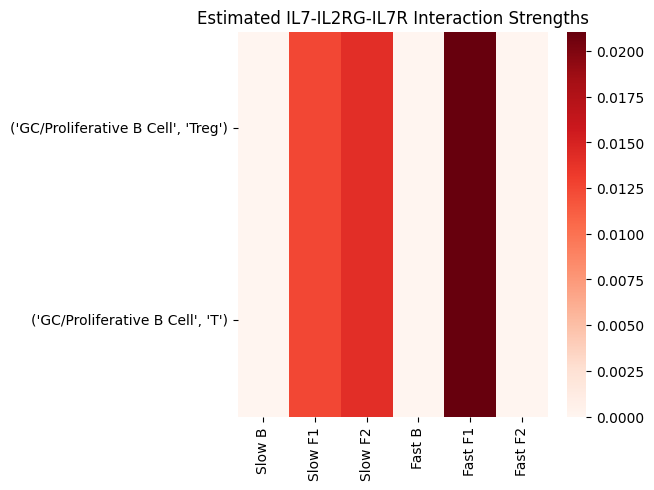

In [51]:
from scipy.stats import zscore
plt.figure(figsize=(5,5))
sns.heatmap(il7il7r,cmap='Reds',yticklabels=1)
plt.title('Estimated IL7-IL2RG-IL7R Interaction Strengths')

In [52]:
temp_interactions = [
    ('GC/Proliferative B Cell', 'Treg'),
 ('GC/Proliferative B Cell', 'T')
]

In [53]:
icoslgicos = pd.DataFrame({
    'Slow B' : slow_b_interaction_score.loc[temp_interactions]['ICOSLG-ICOS'],
    'Slow F1' : slow_f1_interaction_score.loc[temp_interactions]['ICOSLG-ICOS'],
    'Slow F2' : slow_f2_interaction_score.loc[temp_interactions]['ICOSLG-ICOS'],
    'Fast B' : fast_b_interaction_score.loc[temp_interactions]['ICOSLG-ICOS'],
    'Fast F1' : fast_f1_interaction_score.loc[temp_interactions]['ICOSLG-ICOS'],
    'Fast F2' : fast_f2_interaction_score.loc[temp_interactions]['ICOSLG-ICOS']}).fillna(0)

In [54]:
icoslgicos

,Slow B,Slow F1,Slow F2,Fast B,Fast F1,Fast F2
"(GC/Proliferative B Cell, Treg)",0.061751,0.066497,0.048346,0.0,0.076907,0.0
"(GC/Proliferative B Cell, T)",0.061751,0.066497,0.048346,0.0,0.076907,0.0


Text(0.5, 1.0, 'Estimated ICOSLG-ICOS Interaction Strengths')

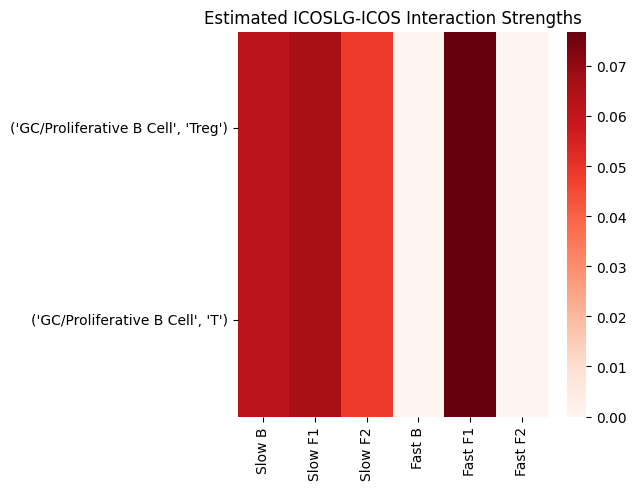

In [55]:
from scipy.stats import zscore
plt.figure(figsize=(5,5))
sns.heatmap(icoslgicos,cmap='Reds',yticklabels=1)
plt.title('Estimated ICOSLG-ICOS Interaction Strengths')

In [56]:
temp_interactions = [
    ('Treg', 'Atypical Memory B Cell'),('T', 'GC/Proliferative B Cell'),('T', 'EIF6+ B Cell')
]

In [57]:
faslgfas = pd.DataFrame({
    'Slow B' : slow_b_interaction_score.loc[temp_interactions]['FASLG-FAS'],
    'Slow F1' : slow_f1_interaction_score.loc[temp_interactions]['FASLG-FAS'],
    'Slow F2' : slow_f2_interaction_score.loc[temp_interactions]['FASLG-FAS'],
    'Fast B' : fast_b_interaction_score.loc[temp_interactions]['FASLG-FAS'],
    'Fast F1' : fast_f1_interaction_score.loc[temp_interactions]['FASLG-FAS'],
    'Fast F2' : fast_f2_interaction_score.loc[temp_interactions]['FASLG-FAS']}).fillna(0)

Text(0.5, 1.0, 'Estimated FASLG-FAS Interaction Strengths')

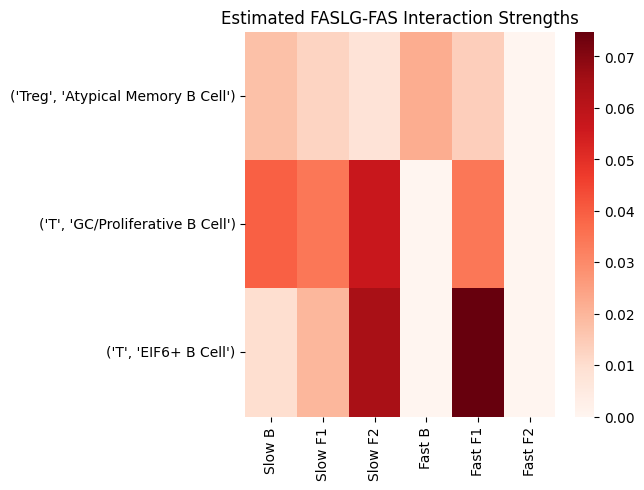

In [58]:
from scipy.stats import zscore
plt.figure(figsize=(5,5))
sns.heatmap(faslgfas,cmap='Reds',yticklabels=1)
plt.title('Estimated FASLG-FAS Interaction Strengths')

# Specific cell subsets

In [59]:
adata_tme = sc.read_h5ad('/home/jupyter/data/ge_korea/results/ge_korea_final_annot_new.h5ad')
adata_tme=adata_tme[~adata_tme.obs['patient'].isin(['E36','E37','E43','E45'])]

In [60]:
adata_b = sc.read_h5ad('/home/jupyter/data/ge_korea/results/ge_korea_b_annotation.h5ad')
adata_b=adata_b[~adata_b.obs['patient'].isin(['E36','E37','E43','E45'])]

In [61]:
adata_tme.obs['annot_final_new'] = pd.concat([adata_tme[~adata_tme.obs['annot_final'].isin(['B'])].obs['annot_final'],
                                   adata_b.obs['annot_3rd']])

/tmp/ipykernel_1490/3946992368.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_tme.obs['annot_final_new'] = pd.concat([adata_tme[~adata_tme.obs['annot_final'].isin(['B'])].obs['annot_final'],


In [62]:
adata_t = sc.read_h5ad('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata_new_correct_progression.h5ad')
adata_t=adata_t[~adata_t.obs['patient'].isin(['E36','E37','E43','E45'])]
temp = adata_t.obs[['patient','progression']].drop_duplicates()
temp.index = temp['patient']
progression_dict = temp['progression'].to_dict()
adata_tme.obs['progression'] = adata_tme.obs['patient'].map(
    progression_dict)

In [63]:
adata_tme = adata_tme[~adata_tme.obs['normal'].isin(['AN','DN'])]

In [64]:
adata_tme.obs['annot_final_new'].unique().tolist()

['Plasma',
 'Activated B Cell',
 'Resting Memory B Cell',
 'Naive B Cell',
 'Atypical Memory B Cell',
 'GC/Proliferative B Cell',
 'EIF6+ B Cell',
 'Epithelial',
 'Capillary Endothelial',
 'Pericyte',
 'iCAF',
 'Venuous Endothelial',
 'SMC',
 'Schwann',
 'Lymphatic Endothelial',
 'C1QC Macrophage',
 'cDC2',
 'Monocyte',
 'CD14 Monocyte',
 'Mast',
 'mregDC',
 'cDC1',
 'SPP1 Macrophage',
 'pDC',
 'Treg',
 'Tactiv Cell',
 'CD8 Tem Cell',
 'Th17',
 'GZMK+ CD8 T progenitor ex Cell',
 'T naive/early memory Cell',
 'Th17/Tc17',
 'NK',
 'gd T Cell',
 'Tc17',
 'CD8 Cytotoxic T Cell',
 'CD8 HSP T cell',
 'Tprolif Cell',
 'NKT',
 'Terminal CD8 Tex Cell']

In [65]:
cell_types = ['Activated B Cell', 'Resting Memory B Cell',
       'Naive B Cell', 'Atypical Memory B Cell',
       'GC/Proliferative B Cell', 'EIF6+ B Cell', 'Treg',
 'Tactiv Cell',
 'CD8 Tem Cell',
 'Th17',
 'GZMK+ CD8 T progenitor ex Cell',
 'T naive/early memory Cell',
 'Th17/Tc17',
 'gd T Cell',
 'Tc17',
 'CD8 Cytotoxic T Cell',
 'CD8 HSP T cell',
 'Tprolif Cell',
 'NKT',
 'Terminal CD8 Tex Cell']
adata_tme = adata_tme[adata_tme.obs['annot_final_new'].isin(
    ['Activated B Cell', 'Resting Memory B Cell',
       'Naive B Cell', 'Atypical Memory B Cell',
       'GC/Proliferative B Cell', 'EIF6+ B Cell', 'Treg',
 'Tactiv Cell',
 'CD8 Tem Cell',
 'Th17',
 'GZMK+ CD8 T progenitor ex Cell',
 'T naive/early memory Cell',
 'Th17/Tc17',
 'gd T Cell',
 'Tc17',
 'CD8 Cytotoxic T Cell',
 'CD8 HSP T cell',
 'Tprolif Cell',
 'NKT',
 'Terminal CD8 Tex Cell']
)]

In [66]:
genes = [
    'CD80','CD86','CXCL13','CD40LG','TGFB1','SELPLG','IL7','IFNG',
    'ICOSLG','FASLG','CCL20','CXCR5','CD28','CD40','SELL','ICOS','FAS',
    'CTLA4','CCR6','TGFBR1','TGFBR2','TGFBR3','IL2RG','IL7R','IFNGR1','IFNGR2',
    'TNFSF13B','TNFRSF13C','TNFRSF13B','SEMA4D','CD72']

In [67]:
avg_b_slow = pd.DataFrame(np.nan, index=cell_types, columns=genes)
avg_f1_slow = pd.DataFrame(np.nan, index=cell_types, columns=genes)
avg_f2_slow = pd.DataFrame(np.nan, index=cell_types, columns=genes)

avg_b_fast = pd.DataFrame(np.nan, index=cell_types, columns=genes)
avg_f1_fast = pd.DataFrame(np.nan, index=cell_types, columns=genes)
avg_f2_fast = pd.DataFrame(np.nan, index=cell_types, columns=genes)

for i in genes:    
    for j in cell_types:
        avg_b_slow.loc[j,i] = adata_tme[(adata_tme.obs['annot_final_new'] == j) & (
            adata_tme.obs['timepoint'] == 'B'
        ) & (adata_tme.obs['progression'] == 'Slow')][:,i].to_df().mean()[0]

        avg_f1_slow.loc[j,i] = adata_tme[(adata_tme.obs['annot_final_new'] == j) & (
            adata_tme.obs['timepoint'] == 'F1'
        ) & (adata_tme.obs['progression'] == 'Slow')][:,i].to_df().mean()[0]

        avg_f2_slow.loc[j,i] = adata_tme[(adata_tme.obs['annot_final_new'] == j) & (
            adata_tme.obs['timepoint'] == 'F2'
        ) & (adata_tme.obs['progression'] == 'Slow')][:,i].to_df().mean()[0]

        avg_b_fast.loc[j,i] = adata_tme[(adata_tme.obs['annot_final_new'] == j) & (
            adata_tme.obs['timepoint'] == 'B'
        ) & (adata_tme.obs['progression'] == 'Fast')][:,i].to_df().mean()[0]

        avg_f1_fast.loc[j,i] = adata_tme[(adata_tme.obs['annot_final_new'] == j) & (
            adata_tme.obs['timepoint'] == 'F1'
        ) & (adata_tme.obs['progression'] == 'Fast')][:,i].to_df().mean()[0]

        avg_f2_fast.loc[j,i] = adata_tme[(adata_tme.obs['annot_final_new'] == j) & (
            adata_tme.obs['timepoint'] == 'F2'
        ) & (adata_tme.obs['progression'] == 'Fast')][:,i].to_df().mean()[0]

In [68]:
interactions = [
    'CD80-CD28','CD86-CD28','CXCL13-CXCR5','CD40LG-CD40','TGFB1-TGFBR1-TGFBR2','TGFB1-TGFBR3',
    'SELPLG-SELL','IL7-IL2RG-IL7R','IFNG-IFNGR1-IFNGR2','ICOSLG-ICOS','FASLG-FAS','CD86-CTLA4',
    'CD80-CTLA4','CCL20-CCR6','TNFSF13B-TNFRSF13C','TNFSF13B-TNFRSF13B','SEMA4D-CD72'
]

In [69]:
import itertools
slow_b_interaction_score = pd.DataFrame(
    np.nan, index=list(itertools.permutations(cell_types,2)), columns=interactions)
slow_f1_interaction_score = pd.DataFrame(
    np.nan, index=list(itertools.permutations(cell_types,2)), columns=interactions)
slow_f2_interaction_score = pd.DataFrame(
    np.nan, index=list(itertools.permutations(cell_types,2)), columns=interactions)
fast_b_interaction_score = pd.DataFrame(
    np.nan, index=list(itertools.permutations(cell_types,2)), columns=interactions)
fast_f1_interaction_score = pd.DataFrame(
    np.nan, index=list(itertools.permutations(cell_types,2)), columns=interactions)
fast_f2_interaction_score = pd.DataFrame(
    np.nan, index=list(itertools.permutations(cell_types,2)), columns=interactions)
for i, j in itertools.permutations(cell_types, 2):
    for k in interactions:
        temp = k.split('-')
        if len(temp) == 2:  
            slow_b_interaction_score.loc[[(i,j)],k] = np.min([
            avg_b_slow.loc[i,k.split('-')[0]],
            avg_b_slow.loc[j,k.split('-')[1]]])
    
            slow_f1_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f1_slow.loc[i,k.split('-')[0]],
                avg_f1_slow.loc[j,k.split('-')[1]]])
                                                           
            slow_f2_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f2_slow.loc[i,k.split('-')[0]],
                avg_f2_slow.loc[j,k.split('-')[1]]])
    
            fast_b_interaction_score.loc[[(i,j)],k] = np.min([
                avg_b_fast.loc[i,k.split('-')[0]],
                avg_b_fast.loc[j,k.split('-')[1]]])
    
            fast_f1_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f1_fast.loc[i,k.split('-')[0]],
                avg_f1_fast.loc[j,k.split('-')[1]]])
    
            fast_f2_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f2_fast.loc[i,k.split('-')[0]],
                avg_f2_fast.loc[j,k.split('-')[1]]])
        if len(temp) == 3:
            slow_b_interaction_score.loc[[(i,j)],k] = np.min([
                avg_b_slow.loc[i,k.split('-')[0]],
                avg_b_slow.loc[j,k.split('-')[1]],
                avg_b_slow.loc[j,k.split('-')[2]]])
    
            slow_f1_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f1_slow.loc[i,k.split('-')[0]],
                avg_f1_slow.loc[j,k.split('-')[1]],
                avg_f1_slow.loc[j,k.split('-')[2]]])
                                                           
            slow_f2_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f2_slow.loc[i,k.split('-')[0]],
                avg_f2_slow.loc[j,k.split('-')[1]],
                avg_f2_slow.loc[j,k.split('-')[2]]])
    
            fast_b_interaction_score.loc[[(i,j)],k] = np.min([
                avg_b_fast.loc[i,k.split('-')[0]],
                avg_b_fast.loc[j,k.split('-')[1]],
                avg_b_fast.loc[j,k.split('-')[2]]])
    
            fast_f1_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f1_fast.loc[i,k.split('-')[0]],
                avg_f1_fast.loc[j,k.split('-')[1]],
                avg_f1_fast.loc[j,k.split('-')[2]]])
    
            fast_f2_interaction_score.loc[[(i,j)],k] = np.min([
                avg_f2_fast.loc[i,k.split('-')[0]],
                avg_f2_fast.loc[j,k.split('-')[1]],
                avg_f2_fast.loc[j,k.split('-')[2]]])

In [70]:
avg_b_slow

,CD80,CD86,CXCL13,CD40LG,TGFB1,SELPLG,IL7,IFNG,ICOSLG,FASLG,...,TGFBR3,IL2RG,IL7R,IFNGR1,IFNGR2,TNFSF13B,TNFRSF13C,TNFRSF13B,SEMA4D,CD72
Activated B Cell,0.013518,0.062662,0.006320,0.000000,0.518707,0.008488,0.019053,0.001198,0.037960,0.000000,...,0.000000,0.279006,0.005210,0.064766,0.142275,0.005837,0.179814,0.200204,0.070934,0.115422
Resting Memory B Cell,0.009330,0.064187,0.000849,0.000000,0.587521,0.003857,0.025489,0.000315,0.027434,0.000753,...,0.002056,0.327235,0.004111,0.069341,0.160082,0.001833,0.222095,0.291698,0.088760,0.074966
Naive B Cell,0.000000,0.015144,0.000000,0.000523,0.620991,0.005770,0.021535,0.000813,0.066171,0.000000,...,0.000000,0.375879,0.004570,0.117458,0.177744,0.004233,0.190907,0.055753,0.044636,0.329116
Atypical Memory B Cell,0.020308,0.135587,0.000000,0.000000,0.640012,0.004129,0.048507,0.004707,0.021567,0.004590,...,0.000000,0.522285,0.000000,0.100288,0.217747,0.022921,0.212038,0.370128,0.127406,0.101982
GC/Proliferative B Cell,0.016709,0.228112,0.000000,0.000000,0.370771,0.000000,0.000000,0.000000,0.061751,0.000000,...,0.000000,0.319274,0.000000,0.027492,0.111351,0.003986,0.309136,0.065944,0.154709,0.173639
EIF6+ B Cell,0.044247,0.098300,0.080824,0.000000,0.459657,0.000000,0.000000,0.046050,0.054475,0.017372,...,0.000000,0.550701,0.000000,0.071152,0.109220,0.000000,0.267276,0.084941,0.048516,0.148098
Treg,0.024636,0.008720,0.133150,0.050003,0.481085,0.351121,0.017656,0.021170,0.001206,0.017491,...,0.025101,1.061011,0.777698,0.076981,0.024928,0.040167,0.002645,0.029907,0.109526,0.006180
Tactiv Cell,0.004003,0.002499,0.032927,0.067530,0.482350,0.239873,0.002685,0.149735,0.001817,0.070694,...,0.057930,0.662167,0.840202,0.093009,0.008700,0.065017,0.003465,0.003274,0.157280,0.007214
CD8 Tem Cell,0.000818,0.003584,0.009633,0.019971,0.897493,0.244759,0.000900,0.037442,0.000492,0.110887,...,0.034379,0.871900,0.887125,0.262681,0.001936,0.043038,0.003151,0.001544,0.130612,0.005290
Th17,0.035006,0.022441,0.078196,0.143873,0.680134,0.400841,0.006176,0.030731,0.000000,0.045038,...,0.024632,1.145627,0.960211,0.165092,0.024783,0.131028,0.002243,0.007204,0.115929,0.019263


In [71]:
b_cells = ['Activated B Cell', 'Resting Memory B Cell',
       'Naive B Cell', 'Atypical Memory B Cell',
       'GC/Proliferative B Cell', 'EIF6+ B Cell']

t_cells = ['Treg',
 'Tactiv Cell',
 'CD8 Tem Cell',
 'Th17',
 'GZMK+ CD8 T progenitor ex Cell',
 'T naive/early memory Cell',
 'Th17/Tc17',
 'gd T Cell',
 'Tc17',
 'CD8 Cytotoxic T Cell',
 'CD8 HSP T cell',
 'Tprolif Cell',
 'NKT',
 'Terminal CD8 Tex Cell']

In [72]:
temp_interactions = [
    ('Terminal CD8 Tex Cell', 'GC/Proliferative B Cell'),
    ('GZMK+ CD8 T progenitor ex Cell', 'GC/Proliferative B Cell')]
cxcl13cxcr5 = pd.DataFrame({
    'Slow B' : slow_b_interaction_score.loc[temp_interactions]['CXCL13-CXCR5'],
    'Slow F1' : slow_f1_interaction_score.loc[temp_interactions]['CXCL13-CXCR5'],
    'Slow F2' : slow_f2_interaction_score.loc[temp_interactions]['CXCL13-CXCR5'],
    'Fast B' : fast_b_interaction_score.loc[temp_interactions]['CXCL13-CXCR5'],
    'Fast F1' : fast_f1_interaction_score.loc[temp_interactions]['CXCL13-CXCR5'],
    'Fast F2' : fast_f2_interaction_score.loc[temp_interactions]['CXCL13-CXCR5']}).fillna(0)

Text(0.5, 1.0, 'Estimated CXCL13-CXCR5 Interaction Strengths')

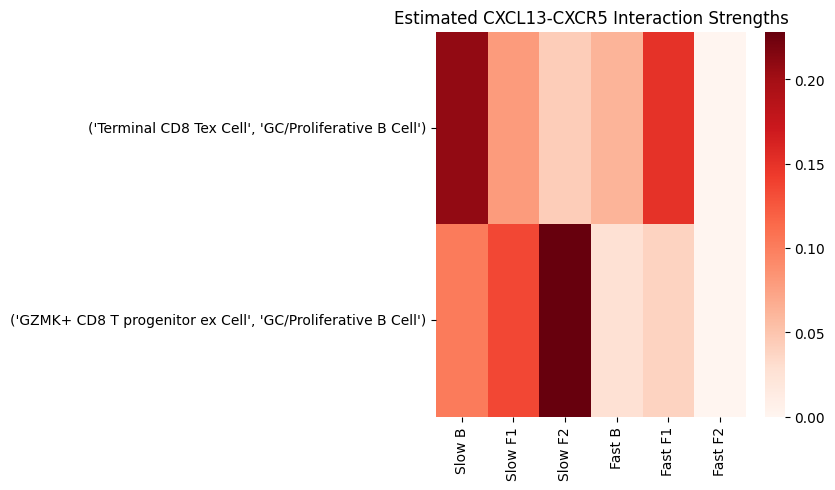

In [73]:
from scipy.stats import zscore
plt.figure(figsize=(5,5))
sns.heatmap(cxcl13cxcr5,cmap='Reds',yticklabels=1)
plt.title('Estimated CXCL13-CXCR5 Interaction Strengths')

In [74]:
cxcl13cxcr5

,Slow B,Slow F1,Slow F2,Fast B,Fast F1,Fast F2
"(Terminal CD8 Tex Cell, GC/Proliferative B Cell)",0.208563,0.079611,0.043164,0.062446,0.150679,0.0
"(GZMK+ CD8 T progenitor ex Cell, GC/Proliferative B Cell)",0.101848,0.135067,0.228389,0.026814,0.038533,0.0


# Summary heatmap

In [75]:
interesting_interactions = pd.concat([
    cxcl13cxcr5.T[('Terminal CD8 Tex Cell', 'GC/Proliferative B Cell')],
    cxcl13cxcr5.T[('GZMK+ CD8 T progenitor ex Cell', 'GC/Proliferative B Cell')],
    icoslgicos.T[('GC/Proliferative B Cell','T')],
    cd80cd28.T[('GC/Proliferative B Cell','T')]
    ],axis=1).T[['Fast B','Fast F1','Fast F2','Slow B','Slow F1','Slow F2']]

In [76]:
interesting_interactions

Fast B   Fast F1  \
Terminal CD8 Tex Cell          GC/Proliferative B Cell  0.062446  0.150679   
GZMK+ CD8 T progenitor ex Cell GC/Proliferative B Cell  0.026814  0.038533   
GC/Proliferative B Cell        T                        0.000000  0.076907   
                               T                        0.000000  0.000000   

                                                        Fast F2    Slow B  \
Terminal CD8 Tex Cell          GC/Proliferative B Cell      0.0  0.208563   
GZMK+ CD8 T progenitor ex Cell GC/Proliferative B Cell      0.0  0.101848   
GC/Proliferative B Cell        T                            0.0  0.061751   
                               T                            0.0  0.016709   

                                                         Slow F1   Slow F2  
Terminal CD8 Tex Cell          GC/Proliferative B Cell  0.079611  0.043164  
GZMK+ CD8 T progenitor ex Cell GC/Proliferative B Cell  0.135067  0.228389  
GC/Proliferative B Cell        T                        0.066497  0.048346  
                               T                        0.021317  0.035609

(array([], dtype=float64), [])

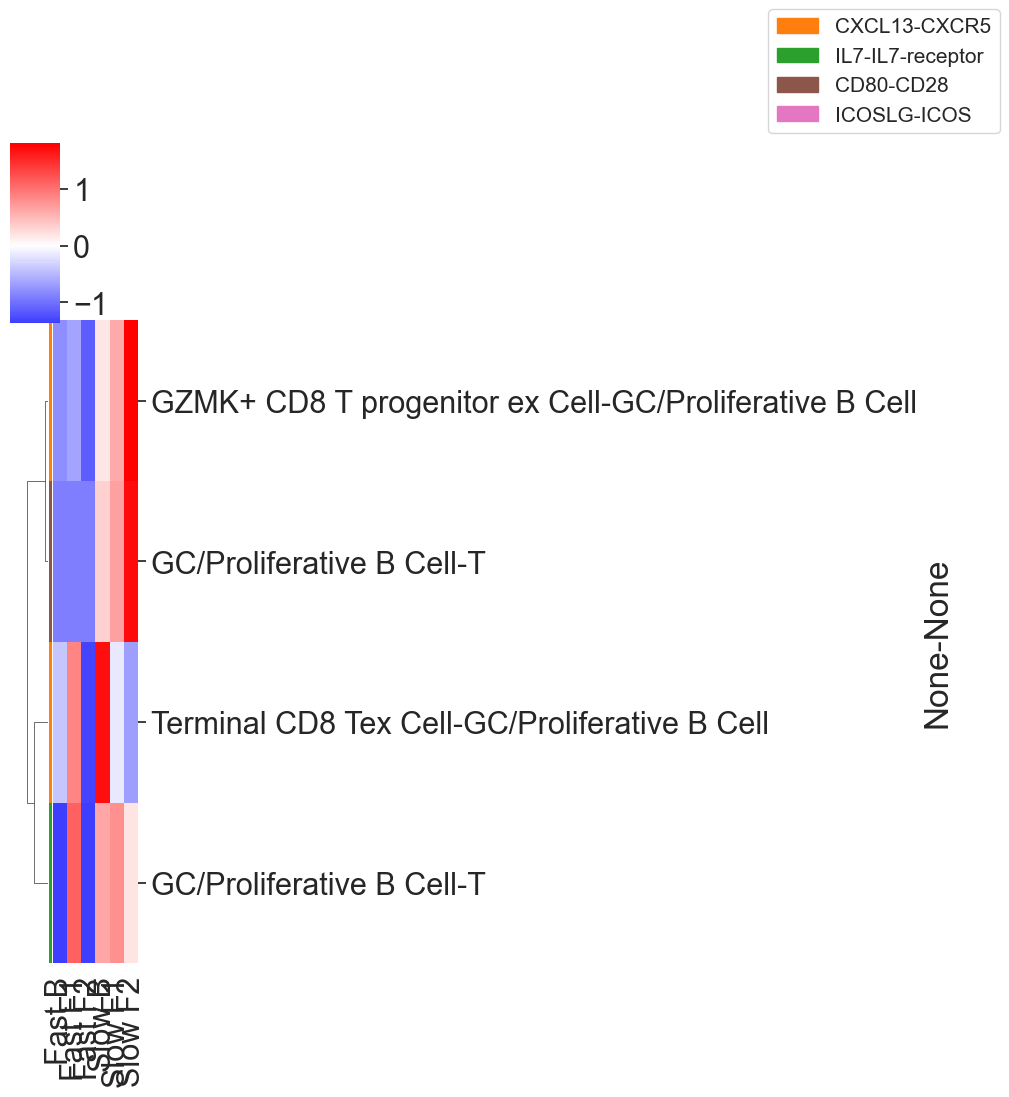

In [77]:
from scipy.stats import zscore
sns.set(font_scale=2)
sns.set_style('white')
lut = dict(zip(['CXCL13-CXCR5',
               'CD80-CD28','ICOSLG-ICOS'], ['tab:orange',
                                                       'tab:green',
                                                       'tab:brown','tab:pink'
                                                        ]))
category_rep = ['CXCL13-CXCR5','CXCL13-CXCR5',
               'CD80-CD28','ICOSLG-ICOS']
row_colors = pd.Series(category_rep).map(lut)
cm = sns.clustermap(zscore(interesting_interactions.T).T,cmap='bwr',
               center=0,row_colors=(row_colors).values,
           col_cluster=False)
orange_patch = mpatches.Patch(color='tab:orange', label='CXCL13-CXCR5')
green_patch = mpatches.Patch(color='tab:green', label='IL7-IL7-receptor')
brown_patch = mpatches.Patch(color='tab:brown', label='CD80-CD28')
pink_patch = mpatches.Patch(color='tab:pink', label='ICOSLG-ICOS')
plt.legend(handles=[orange_patch,green_patch,
                   brown_patch,pink_patch],
           bbox_to_anchor=(20,1.8),fontsize=15) 
plt.xticks(rotation=45,ha='right')

In [78]:
reordered_row_indices = cm.dendrogram_row.reordered_ind

In [79]:
reordered_row_indices

[1, 3, 0, 2]

In [80]:
zscore(interesting_interactions.T).T.iloc[reordered_row_indices,:]

,,Fast B,Fast F1,Fast F2,Slow B,Slow F1,Slow F2
GZMK+ CD8 T progenitor ex Cell,GC/Proliferative B Cell,-0.795057,-0.643881,-1.140992,0.172953,0.601511,1.805467
GC/Proliferative B Cell,T,-0.907246,-0.907246,-0.907246,0.327997,0.668599,1.725140
Terminal CD8 Tex Cell,GC/Proliferative B Cell,-0.407763,0.863639,-1.307586,1.697731,-0.160416,-0.685605
GC/Proliferative B Cell,T,-1.361659,1.116932,-1.361659,0.628485,0.781434,0.196467


[Text(0, 0.5, 'CXCL13-CXCR5'),
 Text(0, 1.5, 'ICOSLG-ICOS'),
 Text(0, 2.5, 'CXCL13-CXCR5'),
 Text(0, 3.5, 'CD80-CD28')]

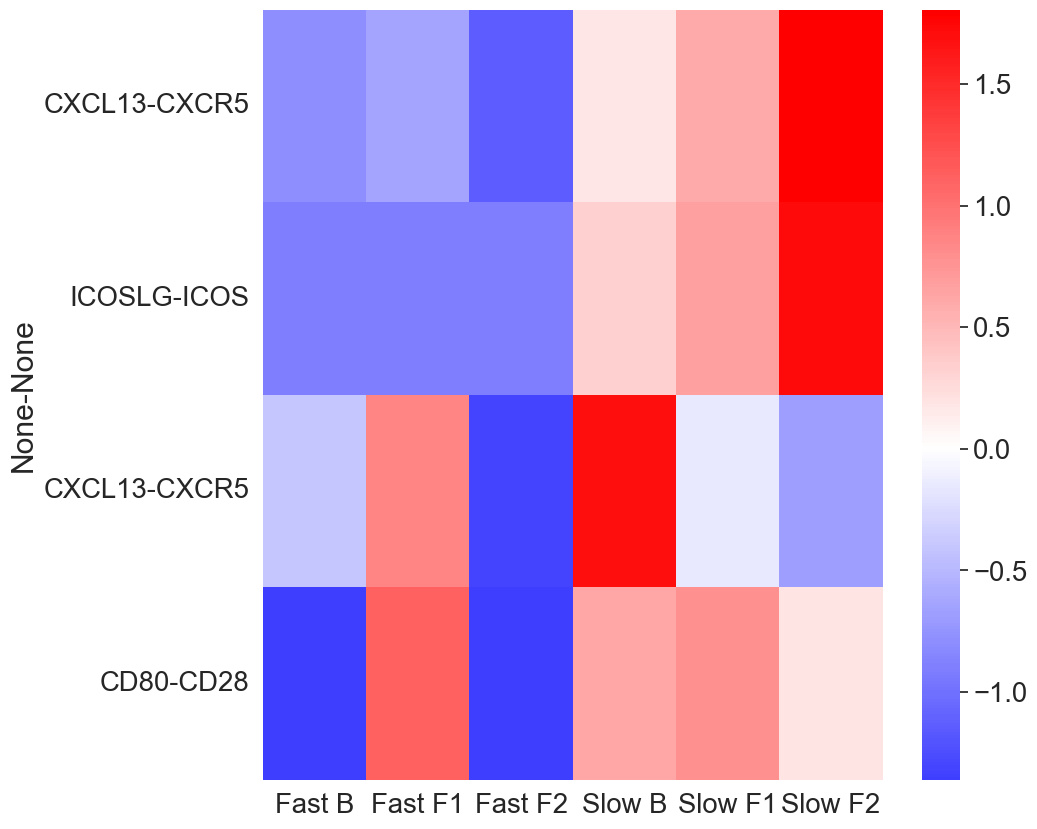

In [81]:
sns.set(font_scale=1.8)
plt.figure(figsize=(10,10))
ax=sns.heatmap(zscore(
    interesting_interactions.T).T.iloc[reordered_row_indices,:],cmap='bwr',
               center=0,
           )
ax.set_yticklabels([
    'CXCL13-CXCR5','ICOSLG-ICOS','CXCL13-CXCR5','CD80-CD28'])